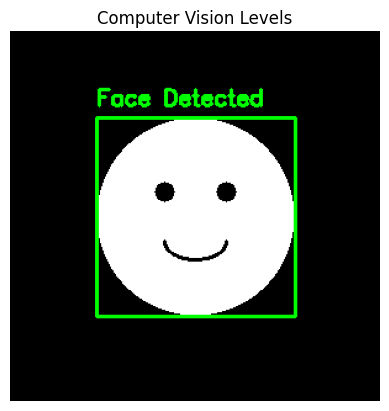

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a blank image (Image Acquisition)
img = np.zeros((300, 300, 3), dtype=np.uint8)

# Step 2: Draw a simple face
cv2.circle(img, (150, 150), 80, (255, 255, 255), -1)   # Face
cv2.circle(img, (125, 130), 8, (0, 0, 0), -1)          # Left Eye
cv2.circle(img, (175, 130), 8, (0, 0, 0), -1)          # Right Eye
cv2.ellipse(img, (150, 170), (25, 15), 0, 0, 180, (0, 0, 0), 2)  # Mouth

# Step 3: Low-Level CV - Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Low-Level CV - Reduce Noise
gray = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 5: Mid-Level CV - Detect Object using Threshold
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

# Step 6: Find Contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 7: High-Level CV - Decision Making
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, "Face Detected", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (0, 255, 0), 2)

# Step 8: Display Result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Computer Vision Levels")
plt.axis("off")
plt.show()